In [17]:
import sys
sys.path.append('..')

import os
import glob
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score

from src.models import RobustDetector
from src.utils import get_freqs, get_freqs_mask

In [18]:
# ---------------------------------------------------------------------------
# Pipeline functions
# ---------------------------------------------------------------------------

def _resolve_ckpt(ckpt_dir, ckpt_index=None):
    """Pick the single .ckpt in *ckpt_dir*. If several exist, use ckpt_index (0-based)."""
    candidates = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
    if len(candidates) == 0:
        raise FileNotFoundError(f"No .ckpt file found in {ckpt_dir}")
    if len(candidates) == 1:
        return candidates[0]
    print("Several checkpoints found:")
    for i, c in enumerate(candidates):
        print(f"  [{i}] {os.path.basename(c)}")
    if ckpt_index is None:
        raise ValueError("Multiple checkpoints found. Set ckpt_index=<index> in build_paths().")
    return candidates[ckpt_index]


def build_paths(train_tag, gen_train_model, attack, gen_test_model,
                base_data_dir="../data/sonics", ckpt_path=None, ckpt_index=None):
    """Derive checkpoint, data and output paths from experiment tags."""
    if ckpt_path is None:
        ckpt_dir = f"../checkpoints/{train_tag}/{gen_train_model}"
        ckpt_path = _resolve_ckpt(ckpt_dir, ckpt_index=ckpt_index)

    if attack is None:
        data_dir = os.path.join(base_data_dir, "noattack", "test")
    else:
        data_dir = os.path.join(base_data_dir, "attack", "test", attack)

    ckpt_parts = ckpt_path.replace("\\", "/").split("/")
    output_train_tag = train_tag
    for part in ckpt_parts:
        if part == "noattack":
            output_train_tag = "train_noattack"
            break
        if part == "attack":
            output_train_tag = "train_attack"
            break

    test_tag = (
        f"test_noattack_{gen_test_model}" if attack is None
        else f"test_attack_{attack}_{gen_test_model}"
    )
    output_path = f"../outputs/tests/{output_train_tag}_{test_tag}.png"

    print(f"CKPT_PATH   : {ckpt_path}")
    print(f"DATA_DIR    : {data_dir}")
    print(f"OUTPUT_PATH : {output_path}")
    return ckpt_path, data_dir, output_path


def slice_model_freq_range(model, new_fmax):
    """Restrict a trained model to [freq_range[0], new_fmax] without retraining.

    Works for log_stft models: slices the first N weight bins corresponding to
    the [fmin, new_fmax] portion of the original logspace grid (same ~bpo density).
    """
    import math
    fmin = model.freq_range[0]
    bpo  = model.bins_per_octave_stft
    n_new = int(math.ceil(bpo * math.log2(new_fmax / fmin)))
    model.linear_proj.weights = torch.nn.Parameter(model.linear_proj.weights.data[:, :n_new])
    model.feature_dim  = n_new
    model.freq_range   = [fmin, new_fmax]
    model.mask         = get_freqs_mask(model.freqs, model.sampling_rate, model.freq_range)
    print(f"Model sliced → freq_range={model.freq_range}, feature_dim={model.feature_dim}")
    return model


def load_model(ckpt_path, freq_range_override=None, seed=42):
    """Load a RobustDetector checkpoint and return (model, device).

    freq_range_override: optional [fmin, fmax] to restrict the model's freq range
    without retraining (log_stft models only).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = RobustDetector.load_from_checkpoint(ckpt_path)
    model.eval()
    device = torch.device('cpu')
    model = model.to(device)
    if freq_range_override is not None:
        slice_model_freq_range(model, new_fmax=freq_range_override[1])
    print(
        f"Model loaded | transform={model.transform_type} "
        f"| log_stft={model.log_stft} | use_conv={model.use_convolution} "
        f"| freq_range={model.freq_range}"
    )
    return model, device


def load_data(data_dir, model, gen_test_model, sf_lo, sf_hi):
    """Load AI / human fakeprints and return a data dict."""
    def _load_class(label):
        freqs = get_freqs(
            n_fft=model.n_fft, sr=model.sampling_rate,
            log=(model.transform_type == 'cqt'),
            bins_per_octave=model.bins_per_octave,
        )
        mask = get_freqs_mask(freqs, model.sampling_rate, model.freq_range)
        fps, speed_factors = [], []
        subdir = (
            gen_test_model if label == 1
            else ('human_44100' if model.sampling_rate == 44100 else 'human')
        )
        for path in sorted(glob.glob(f"{data_dir}/{subdir}/*.npz")):
            d = np.load(path)
            fp = d[model.transform_type][:, mask]
            sf = d.get('speed_factors', np.ones(len(fp)))
            valid = ~(np.isnan(fp).any(axis=1) | np.isinf(fp).any(axis=1))
            fps.append(fp[valid])
            speed_factors.append(sf[valid])
        concat_sf = np.concatenate(speed_factors)
        print(f"[{subdir}] Number of different speed factors: {len(np.unique(concat_sf))}")
        return np.concatenate(fps), concat_sf

    ai_fp, ai_sf = _load_class(1)
    hu_fp, hu_sf = _load_class(0)

    print(f"\nSpeed factor range [HUMAN]: {hu_sf.min():.3f}, {hu_sf.max():.3f}")
    print(f"Speed factor range [AI]: {ai_sf.min():.3f}, {ai_sf.max():.3f}")

    n_ai, n_hu = len(ai_fp), len(hu_fp)
    fps    = np.concatenate([ai_fp, hu_fp])
    labels = np.concatenate([np.ones(n_ai), np.zeros(n_hu)])
    sfs    = np.concatenate([ai_sf, hu_sf])
    m_sf   = (sfs >= sf_lo) & (sfs <= sf_hi)

    print(f"\nUnconstrained test set: {n_ai} AI + {n_hu} Human = {n_ai + n_hu} total")
    print(
        f"Samples with {sf_lo} <= speed factor <= {sf_hi}: {m_sf.sum()} "
        f"(AI: {(m_sf & (labels == 1)).sum()}, Human: {(m_sf & (labels == 0)).sum()})"
    )
    return dict(
        fps=fps, labels=labels, sfs=sfs, m_sf=m_sf,
        n_ai=n_ai, n_hu=n_hu, ai_sf=ai_sf, hu_sf=hu_sf,
    )


def plot_speed_factors(data, sf_lo, sf_hi):
    """Plot speed-factor histograms for the full test set."""
    plt.figure(figsize=(8, 4))
    plt.hist(data['hu_sf'], bins=500, alpha=0.7, label='Human', color='steelblue')
    plt.hist(data['ai_sf'], bins=500, alpha=0.7, label='AI', color='tomato')
    plt.xlabel('Speed Factor')
    plt.ylabel('Count')
    plt.title('Speed factor distribution (all test tracks)')
    ax = plt.gca()
    ax.axvspan(sf_lo, sf_hi, color='pink', alpha=0.25, hatch='///',
               label='Speed factor during training')
    plt.legend()
    plt.show()


def run_inference(model, device, data):
    """Forward pass on all test fakeprints; return probabilities."""
    with torch.inference_mode():
        x = torch.from_numpy(data['fps']).float().to(device)
        if model.log_stft:
            x = model.stft_to_log(x)
        logits, _ = model(x, convolve=model.use_convolution)
        probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()
    print(f"Probs range (all tracks): [{probs.min():.3f}, {probs.max():.3f}]")
    return probs


def plot_and_save_results(probs, data, sf_lo, sf_hi, output_path):
    """Compute metrics, plot results and save figures."""
    labels  = data['labels']
    sfs     = data['sfs']
    m_sf    = data['m_sf']
    n_ai    = data['n_ai']

    probs_sf  = probs[m_sf]
    labels_sf = labels[m_sf]

    # --- optimal threshold via F1 ---
    thresholds = np.linspace(0, 1, 201)
    f1_scores  = [f1_score(labels_sf, probs_sf >= t, zero_division=0) for t in thresholds]
    best_t  = thresholds[np.argmax(f1_scores)]
    best_f1 = max(f1_scores)
    print(f"Optimal threshold: {best_t:.3f}  |  Best F1: {best_f1:.4f}")

    # --- Figure 1 : classification histogram + ROC + F1-vs-threshold ---
    fpr, tpr, _ = roc_curve(labels_sf, probs_sf)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.hist(probs_sf[labels_sf == 0], bins=40, alpha=0.7, label='Human', color='steelblue')
    ax.hist(probs_sf[labels_sf == 1], bins=40, alpha=0.7, label='AI',    color='tomato')
    ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold={best_t:.2f}')
    ax.set_xlabel('Predicted probability (AI)')
    ax.set_ylabel('Count')
    ax.set_title('Score distribution (all test tracks)')
    ax.legend()

    ax = axes[1]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()

    ax = axes[2]
    ax.plot(thresholds, f1_scores, color='mediumseagreen', lw=2)
    ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5,
               label=f'Best t={best_t:.2f} (F1={best_f1:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 vs Threshold')
    ax.legend()

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Saved \u2192 {output_path}")
    plt.show()

    # --- Figure 2 : F1 vs speed factor (unconstrained) ---
    ai_probs = probs[:n_ai]
    ai_sfs   = sfs[:n_ai]
    hu_probs = probs[n_ai:]

    sf_min, sf_max = float(ai_sfs.min()), float(ai_sfs.max())
    if sf_max <= sf_min:
        sf_max = sf_min + 1e-9
    bins = np.linspace(sf_min, sf_max, 15)
    bin_centers, bin_f1s = [], []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask_ai = (
            (ai_sfs >= lo) & (ai_sfs < hi) if i < len(bins) - 2
            else (ai_sfs >= lo) & (ai_sfs <= hi)
        )
        k = int(mask_ai.sum())
        if k < 5:
            continue
        p_bin = np.concatenate([ai_probs[mask_ai], hu_probs])
        l_bin = np.concatenate([np.ones(k), np.zeros(len(hu_probs))])
        f1_b  = f1_score(l_bin, p_bin >= best_t, zero_division=0)
        bin_centers.append((lo + hi) / 2)
        bin_f1s.append(f1_b)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axvspan(sf_lo, sf_hi, color='pink', alpha=0.25, zorder=0,
               hatch='////', edgecolor='crimson',
               label='speed factor during training')
    ax.plot(bin_centers, bin_f1s, marker='o', color='mediumpurple', lw=2, zorder=2)
    ax.set_xlabel('Speed Factor (AI samples, bin center)')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 vs speed factor \u2014 unconstrained test tracks')
    handles, leg_labels = ax.get_legend_handles_labels()
    by_label = OrderedDict(zip(leg_labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    plt.tight_layout()

    base_dir = os.path.dirname(output_path)
    out_path = os.path.join(base_dir, 'f1_vs_sf_' + os.path.basename(output_path))
    os.makedirs(base_dir, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f"Saved \u2192 {out_path}")
    plt.show()

Several checkpoints found:
  [0] robustdetector-sonics-log_stft-use_conv-lamb=0.1-v1.ckpt
  [1] robustdetector-sonics-log_stft-use_conv-lamb=0.1-v2.ckpt
  [2] robustdetector-sonics-log_stft-use_conv-lamb=0.1-v3.ckpt
  [3] robustdetector-sonics-log_stft-use_conv-lamb=0.1.ckpt
CKPT_PATH   : ../checkpoints/noattack/udio_v120/robustdetector-sonics-log_stft-use_conv-lamb=0.1-v1.ckpt
DATA_DIR    : ../data/sonics/attack/test/continuous
OUTPUT_PATH : ../outputs/tests/train_noattack_test_attack_continuous_udio_v120.png
Model loaded | transform=stft | log_stft=True | use_conv=True | freq_range=[1000, 8000]
[udio_v120] Number of different speed factors: 1858
[human] Number of different speed factors: 2572

Speed factor range [HUMAN]: 0.502, 2.000
Speed factor range [AI]: 0.507, 2.000

Unconstrained test set: 1858 AI + 2572 Human = 4430 total
Samples with 0.7 <= speed factor <= 1.4: 1977 (AI: 825, Human: 1152)


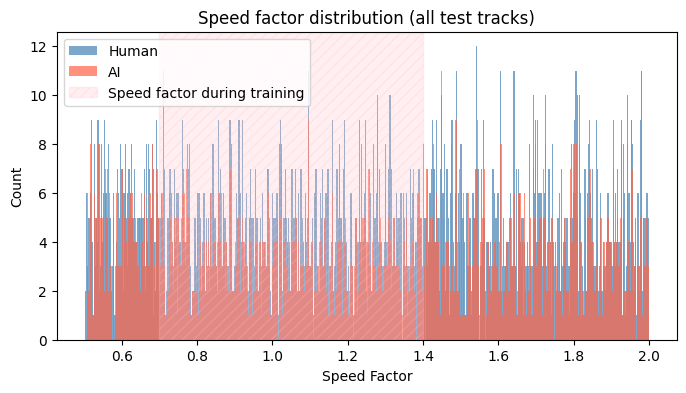

Probs range (all tracks): [0.002, 1.000]
Optimal threshold: 0.020  |  Best F1: 0.7073
Saved → ../outputs/tests/train_noattack_test_attack_continuous_udio_v120.png


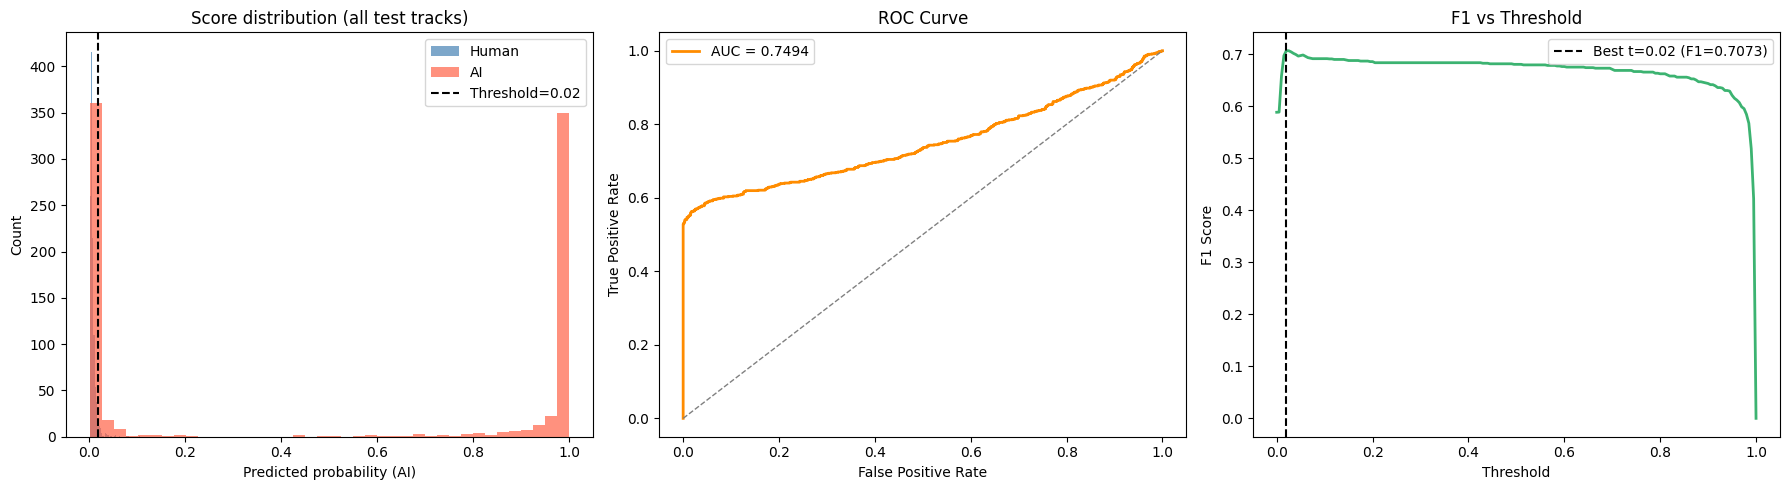

/var/folders/15/bg2nr2kn78l2251qrjqx9r2c0000gn/T/ipykernel_60293/2647662603.py:251: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(sf_lo, sf_hi, color='pink', alpha=0.25, zorder=0,


Saved → ../outputs/tests/f1_vs_sf_train_noattack_test_attack_continuous_udio_v120.png


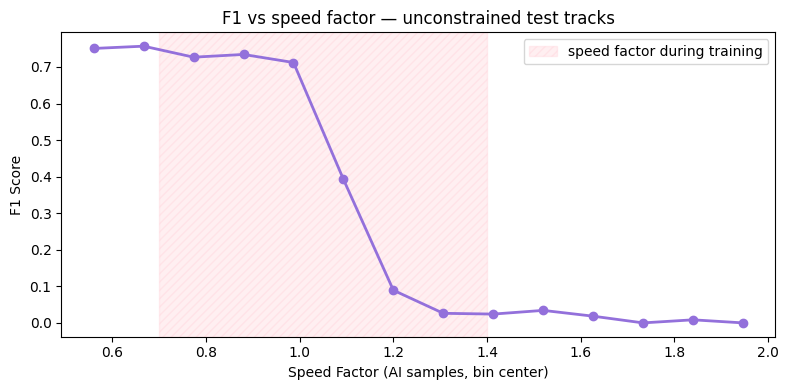

In [20]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

##TRAIN
train_tag       = "noattack"
gen_train_model = "udio_v120"

##TEST
attack          = "continuous"
gen_test_model  = "udio_v120"

SF_LO, SF_HI = 0.7, 1.4

# Optional: restrict the model to a sub-range without retraining (log_stft only).
# Set to None to use the model's original freq_range.
FREQ_RANGE_OVERRIDE = None   # e.g. [1000, 5000]

# ---------------------------------------------------------------------------
# Run pipeline
# ---------------------------------------------------------------------------

ckpt_path, data_dir, output_path = build_paths(
    train_tag, gen_train_model, attack, gen_test_model, ckpt_index=0
)

model, device = load_model(ckpt_path, freq_range_override=FREQ_RANGE_OVERRIDE)

data = load_data(data_dir, model, gen_test_model, SF_LO, SF_HI)

plot_speed_factors(data, SF_LO, SF_HI)

probs = run_inference(model, device, data)

plot_and_save_results(probs, data, SF_LO, SF_HI, output_path)